# 01 — Data Pipeline: Raw CSV → Parquet Cache

The raw CSV is ~4.5 GB and 609 columns. Loading all of it into memory at once is unnecessary and slow.  
This notebook does three things:
1. Reads just the CSV header to identify which columns to keep
2. Streams the file in 100k-row chunks, dropping `delete` rows and unused columns on the fly
3. Writes a compressed Parquet file (~200 MB) that every downstream notebook reads in seconds

**Run this once.** After the Parquet exists, skip straight to notebook 02.

In [1]:
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT   = Path('/Users/chaithanyapakala/Downloads/NLP_FinalProject')
RAW_CSV   = PROJECT / 'Earnings_ATC_until_2026-04-21.csv'
DATA_DIR  = PROJECT / 'data'
DATA_DIR.mkdir(exist_ok=True)
(DATA_DIR / 'prices').mkdir(exist_ok=True)
(DATA_DIR / 'universe').mkdir(exist_ok=True)

SIGNALS_PARQUET = DATA_DIR / 'signals.parquet'

print(f'CSV size : {RAW_CSV.stat().st_size / 1e9:.2f} GB')

CSV size : 4.47 GB


## 1.1 Column Selection

Of the 609 columns we keep three groups:
- **Identifier columns** (~20): SignalType, dates, ticker, sector, company metadata
- **Signal columns** (13): 12 EventScore variants + `ATCClassifierScore`
- **AspectTheme columns** (~405): the 567-cell sentiment matrix **minus Fluff and Filler** — the handout explicitly calls these noise classes and says not to use them as predictive features (a signal built purely on Fluff/Filler should generate ≈0 alpha; we'll use it as our placebo sanity-check later)

Dropping Fluff/Filler up-front saves memory and avoids accidentally leaking noise into the model.

In [2]:
# Read header only — zero data rows, just column names
all_cols = pd.read_csv(RAW_CSV, nrows=0).columns.tolist()
print(f'Total columns in raw CSV: {len(all_cols)}')

# ── Identifier / metadata columns ─────────────────────────────────────────────
ID_COLS = [
    'SignalType', 'DocDate', 'BESTTICKER', 'DocID', 'KEYDEVID',
    'MOSTIMPORTANTDATEUTC', 'COMPANYNAME', 'COMPANYID',
    'SIMPLEINDUSTRYDESCRIPTION', 'SECTOR', 'COUNTRY',
    'EXCHANGE', 'EX_CODE', 'QTR_YEAR',
    'DOCSECTIONCOUNT', 'DOCSENTENCECOUNT', 'Sentences',
    'GVKEY', 'CIK', 'ISIN',
]
ID_COLS = [c for c in ID_COLS if c in all_cols]   # guard against any typos

# ── EventScore columns (all 12) ────────────────────────────────────────────────
EVENT_COLS = [c for c in all_cols if c.startswith('Event')]

# ── ATCClassifierScore ─────────────────────────────────────────────────────────
ATC_COLS = [c for c in all_cols if c == 'ATCClassifierScore']

# ── AspectTheme: drop Fluff and Filler ────────────────────────────────────────
DROP_ASPECTS = {'Fluff', 'Filler'}
ASPECT_COLS  = [
    c for c in all_cols
    if c.startswith('AspectTheme')
    and not any(f'AspectTheme_{a}_' in c or f'AspectTheme_{a} ' in c
                for a in DROP_ASPECTS)
]

# ── Save Fluff/Filler cols separately (needed for placebo test in notebook 04) ─
PLACEBO_COLS = [c for c in all_cols
                if c.startswith('AspectTheme')
                and c not in ASPECT_COLS]

KEEP_COLS = ID_COLS + EVENT_COLS + ATC_COLS + ASPECT_COLS

print(f'Keeping {len(KEEP_COLS)} columns:')
print(f'  Identifiers : {len(ID_COLS)}')
print(f'  EventScores : {len(EVENT_COLS)}')
print(f'  ATC score   : {len(ATC_COLS)}')
print(f'  AspectTheme : {len(ASPECT_COLS)}  (dropped {len(PLACEBO_COLS)} Fluff/Filler)')

Total columns in raw CSV: 609
Keeping 438 columns:
  Identifiers : 20
  EventScores : 12
  ATC score   : 1
  AspectTheme : 405  (dropped 162 Fluff/Filler)


## 1.2 Chunked CSV Load → Parquet

We stream through the CSV in 100k-row chunks. For each chunk we:
- Drop rows where `SignalType == 'delete'` (corrupt/invalidated per the handout)
- Select only `KEEP_COLS`

The chunks are concatenated and written to Parquet. On a laptop this takes 3–8 minutes;  
after that every notebook loads the Parquet in under 10 seconds.

In [3]:
CHUNK_SIZE = 100_000

# These ID columns can be null in some chunks but not others.
# When a chunk has no nulls, pandas infers int64; when it does have nulls it uses float64.
# PyArrow's incremental ParquetWriter enforces the schema from the first chunk and
# rejects the dtype mismatch on later chunks. Pre-specifying float64 keeps dtype
# consistent across ALL chunks regardless of whether nulls appear.
FORCE_FLOAT = {c: float for c in ['KEYDEVID', 'GVKEY', 'CIK', 'COMPANYID']
               if c in KEEP_COLS}
print(f'Forcing float64 on: {list(FORCE_FLOAT.keys())}')

writer      = None
total_kept  = 0
total_drop  = 0
schema      = None

reader = pd.read_csv(
    RAW_CSV,
    usecols=KEEP_COLS,
    chunksize=CHUNK_SIZE,
    low_memory=False,
    dtype=FORCE_FLOAT,      # consistent dtype across all chunks → no schema drift
)

for i, chunk in enumerate(reader):
    n_before   = len(chunk)
    chunk      = chunk[chunk['SignalType'] != 'delete'].copy()
    total_drop += n_before - len(chunk)
    total_kept += len(chunk)

    # Parse datetimes once per chunk (cheaper than post-hoc on the full df)
    chunk['DocDate']              = pd.to_datetime(chunk['DocDate'])
    chunk['MOSTIMPORTANTDATEUTC'] = pd.to_datetime(
        chunk['MOSTIMPORTANTDATEUTC'], utc=True, errors='coerce'
    )

    # Write incrementally so we never hold the full dataset in RAM
    table = pa.Table.from_pandas(chunk, preserve_index=False)
    if writer is None:
        schema = table.schema
        writer = pq.ParquetWriter(SIGNALS_PARQUET, schema, compression='snappy')
    else:
        # Defensive cast — catches any remaining column that still drifts between chunks
        try:
            table = table.cast(schema)
        except Exception:
            table = table.cast(schema, safe=False)
    writer.write_table(table)

    if i % 5 == 0:
        print(f'  chunk {i:3d} | kept so far: {total_kept:>9,} | dropped delete: {total_drop:,}')

writer.close()
print(f'\nDone. Rows kept: {total_kept:,}  |  delete rows dropped: {total_drop:,}')
print(f'Parquet size : {SIGNALS_PARQUET.stat().st_size / 1e6:.1f} MB')

Forcing float64 on: ['KEYDEVID', 'GVKEY', 'CIK', 'COMPANYID']


  chunk   0 | kept so far:   100,000 | dropped delete: 0


  chunk   5 | kept so far:   600,000 | dropped delete: 0


  chunk  10 | kept so far: 1,100,000 | dropped delete: 0


  chunk  15 | kept so far: 1,600,000 | dropped delete: 0


  chunk  20 | kept so far: 2,100,000 | dropped delete: 0


  chunk  25 | kept so far: 2,600,000 | dropped delete: 0



Done. Rows kept: 2,738,206  |  delete rows dropped: 2,231
Parquet size : 318.8 MB


## 1.3 Validation

Quick sanity-check that the Parquet round-trips correctly and the key columns look sane before any downstream work depends on them.

In [4]:
df = pd.read_parquet(SIGNALS_PARQUET)

print('=== Shape ===')
print(f'Rows: {len(df):,}   Cols: {df.shape[1]}')

print('\n=== SignalType distribution ===')
print(df['SignalType'].value_counts().to_string())

print('\n=== Date range ===')
print(f"DocDate : {df['DocDate'].min().date()} → {df['DocDate'].max().date()}")

print('\n=== Coverage ===')
print(f"Unique tickers (BESTTICKER) : {df['BESTTICKER'].nunique():,}")
print(f"Unique calls   (DocID)      : {df['DocID'].nunique():,}")

print('\n=== ATCClassifierScore stats (Total slice) ===')
print(df.loc[df.SignalType=='Total', 'ATCClassifierScore'].describe().round(4).to_string())

print('\n=== Null counts (key columns) ===')
key_cols = ['ATCClassifierScore', 'MOSTIMPORTANTDATEUTC', 'BESTTICKER', 'SECTOR']
print(df[key_cols].isnull().sum().to_string())

assert 'delete' not in df['SignalType'].values, 'delete rows still present!'
print('\nAll assertions passed.')

=== Shape ===
Rows: 2,738,206   Cols: 438

=== SignalType distribution ===
SignalType
Total           376790
Executives      376036
Presentation    373808
Answer          359535
Question        351494
Analysts        343534
CEO             303854
CFO             253155

=== Date range ===
DocDate : 2010-01-04 → 2026-04-21

=== Coverage ===
Unique tickers (BESTTICKER) : 17,636


Unique calls   (DocID)      : 376,790

=== ATCClassifierScore stats (Total slice) ===
count    376790.0000
mean          0.0153
std           0.0326
min          -0.2325
25%          -0.0022
50%           0.0152
75%           0.0323
max           0.2865

=== Null counts (key columns) ===


ATCClassifierScore        0
MOSTIMPORTANTDATEUTC    387
BESTTICKER              193
SECTOR                    0

All assertions passed.


## 1.4 Quick EDA

Four charts to build intuition before touching any backtest code:
- Score distribution — is it roughly centered?
- Call volume per year — any coverage gaps?
- Sector mix — are we heavily concentrated in any GICS sector?
- Median ATC by sector — do sectors have different baseline score levels? (Important for later sector-neutralization.)

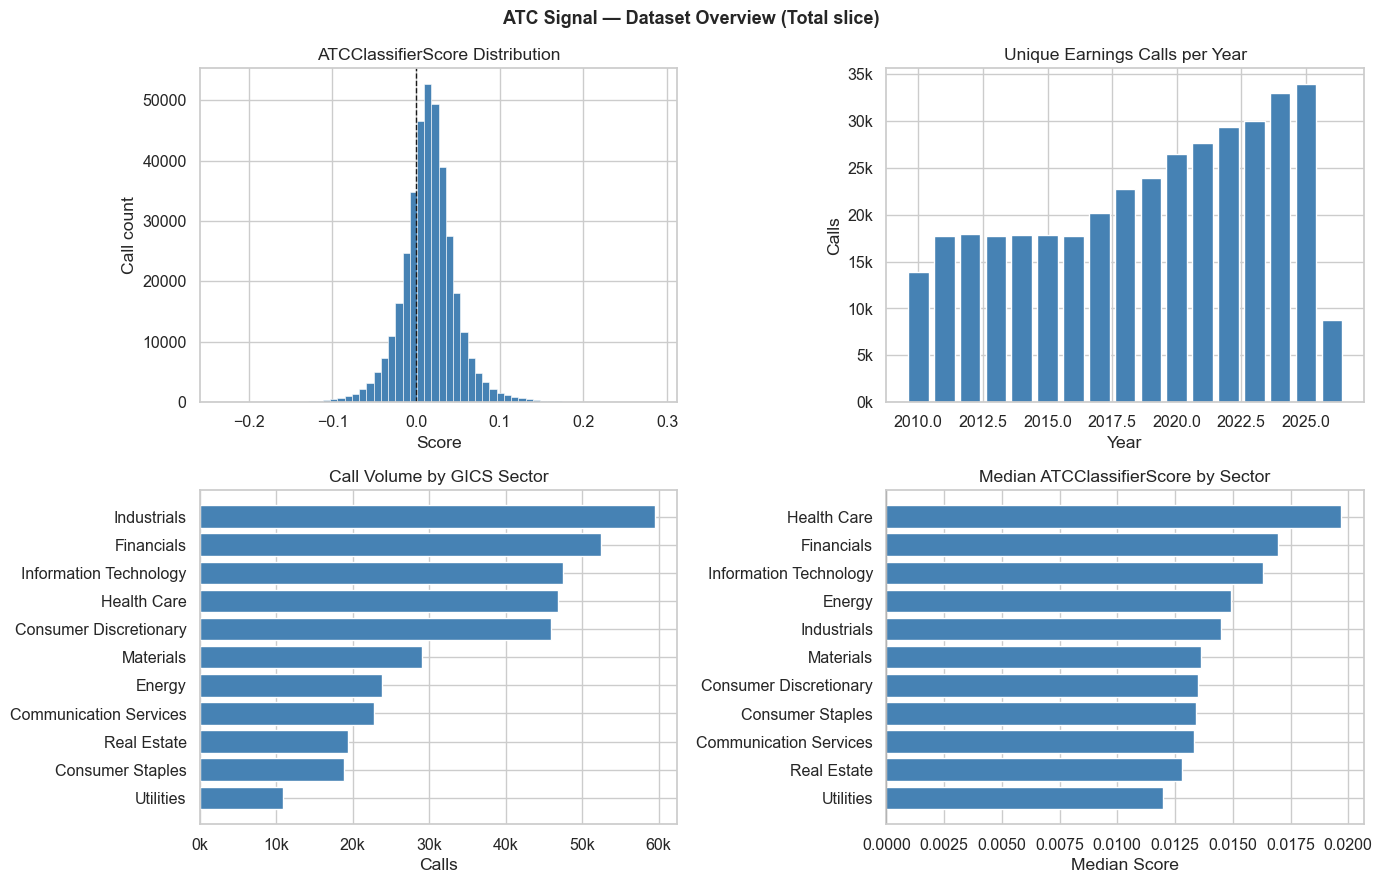

Saved → data/eda_overview.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

total = df[df['SignalType'] == 'Total'].copy()
total['Year'] = total['DocDate'].dt.year

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('ATC Signal — Dataset Overview (Total slice)', fontsize=13, fontweight='bold')

# ── 1. ATCClassifierScore distribution ────────────────────────────────────────
ax = axes[0, 0]
ax.hist(total['ATCClassifierScore'].dropna(), bins=60,
        color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(0, color='k', lw=1, ls='--')
ax.set_title('ATCClassifierScore Distribution')
ax.set_xlabel('Score')
ax.set_ylabel('Call count')

# ── 2. Unique calls per year ───────────────────────────────────────────────────
ax = axes[0, 1]
calls_yr = total.groupby('Year')['DocID'].nunique()
ax.bar(calls_yr.index, calls_yr.values, color='steelblue')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.set_title('Unique Earnings Calls per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Calls')

# ── 3. Calls by sector ────────────────────────────────────────────────────────
ax = axes[1, 0]
sc = total['SECTOR'].value_counts()
ax.barh(sc.index[::-1], sc.values[::-1], color='steelblue')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.set_title('Call Volume by GICS Sector')
ax.set_xlabel('Calls')

# ── 4. Median ATC by sector ───────────────────────────────────────────────────
ax = axes[1, 1]
med = total.groupby('SECTOR')['ATCClassifierScore'].median().sort_values()
colors = ['#e74c3c' if v < 0 else 'steelblue' for v in med.values]
ax.barh(med.index, med.values, color=colors)
ax.axvline(0, color='k', lw=0.8)
ax.set_title('Median ATCClassifierScore by Sector')
ax.set_xlabel('Median Score')

plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → data/eda_overview.png')

## 1.5 Save Column Lists for Downstream Notebooks

Serialize the column groupings so later notebooks don't need to re-derive them from the raw CSV header.

In [6]:
import json

col_registry = {
    'id_cols'      : ID_COLS,
    'event_cols'   : EVENT_COLS,
    'atc_cols'     : ATC_COLS,
    'aspect_cols'  : ASPECT_COLS,
    'placebo_cols' : PLACEBO_COLS,   # Fluff + Filler — used only in notebook 04 placebo test
}

with open(DATA_DIR / 'col_registry.json', 'w') as f:
    json.dump(col_registry, f, indent=2)

print('Saved column registry → data/col_registry.json')
for k, v in col_registry.items():
    print(f'  {k:15s}: {len(v)} cols')

Saved column registry → data/col_registry.json
  id_cols        : 20 cols
  event_cols     : 12 cols
  atc_cols       : 1 cols
  aspect_cols    : 405 cols
  placebo_cols   : 162 cols
